# Decision Tree Classification – Airline Customer Satisfaction

## Step 1: Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    f1_score
)
from sklearn.linear_model import LogisticRegression

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Step 2: Load & Explore the Dataset

In [3]:
file_path = "C:\\Users\\DajahV01\\Desktop\\DHF Assignment\\28. Decision Tree Model Evaluation\\Invistico_Airline.csv"

In [4]:
df = pd.read_csv(file_path)

# Display first five rows
df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


In [6]:
# Dataset dimensions
print(df.shape)


(129880, 22)


In [7]:
# Data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

In [8]:
# Summary statistics
df.describe()



,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [9]:
# Missing values
df.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

## Step 3: Handle Missing Values

As seen above one column has 393 missing values.

In [13]:
# Fill missing values with median of the column

df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(
    df["Arrival Delay in Minutes"].median()
)


In [14]:
# Verify
df.isnull().sum()

satisfaction                         0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Seat comfort                         0
Departure/Arrival time convenient    0
Food and drink                       0
Gate location                        0
Inflight wifi service                0
Inflight entertainment               0
Online support                       0
Ease of Online booking               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Cleanliness                          0
Online boarding                      0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
dtype: int64

## Step 4: Encode Categorical Variables

Decision Trees require numerical inputs.

In [15]:
encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,1,0,65,1,1,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,1,0,47,1,0,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,1,0,15,1,1,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,1,0,60,1,1,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,1,0,70,1,1,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0


## Step 5: Define Features and Target

In [16]:
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

print(X.shape)
print(y.shape)

(129880, 21)
(129880,)


## Step 6: Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

## Step 7: Hyperparameter Tuning with GridSearchCV

Search for the best Decision Tree.

In [19]:
param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state = 42),
    param_grid=param_grid,
    cv=5,
    scoring = "f1",
    n_jobs = -1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}


## Step 8: Train the Final Decision Tree

In [20]:
best_tree = grid_search.best_estimator_

best_tree.fit(X_train, y_train)

DecisionTreeClassifier(min_samples_split=10, random_state=42)

## Step 9: Predictions

In [21]:
y_pred = best_tree.predict(X_test)

## Step 10: Evaluate the Model

Confusion Matrix

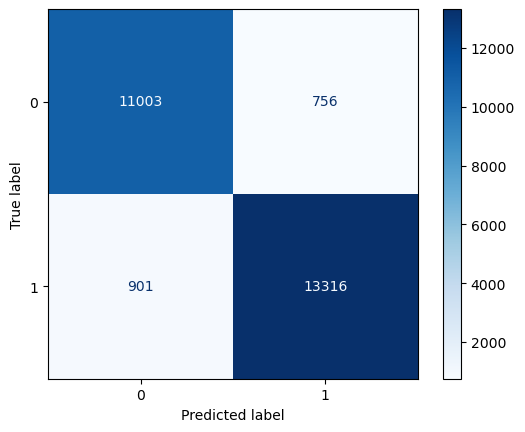

In [23]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap = "Blues")
plt.show()

### Accuracy

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.936210348013551


### F1 Score

Assuming

- Satisfied = 1

In [25]:
f1 = f1_score(y_test, y_pred, pos_label=1)

print("F1 Score:", f1)

F1 Score: 0.9414259959701652


### Classification Report

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93     11759
           1       0.95      0.94      0.94     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976



## Step 11: Visualize the Decision Tree

To keep the visualization readable, limit the displayed depth.

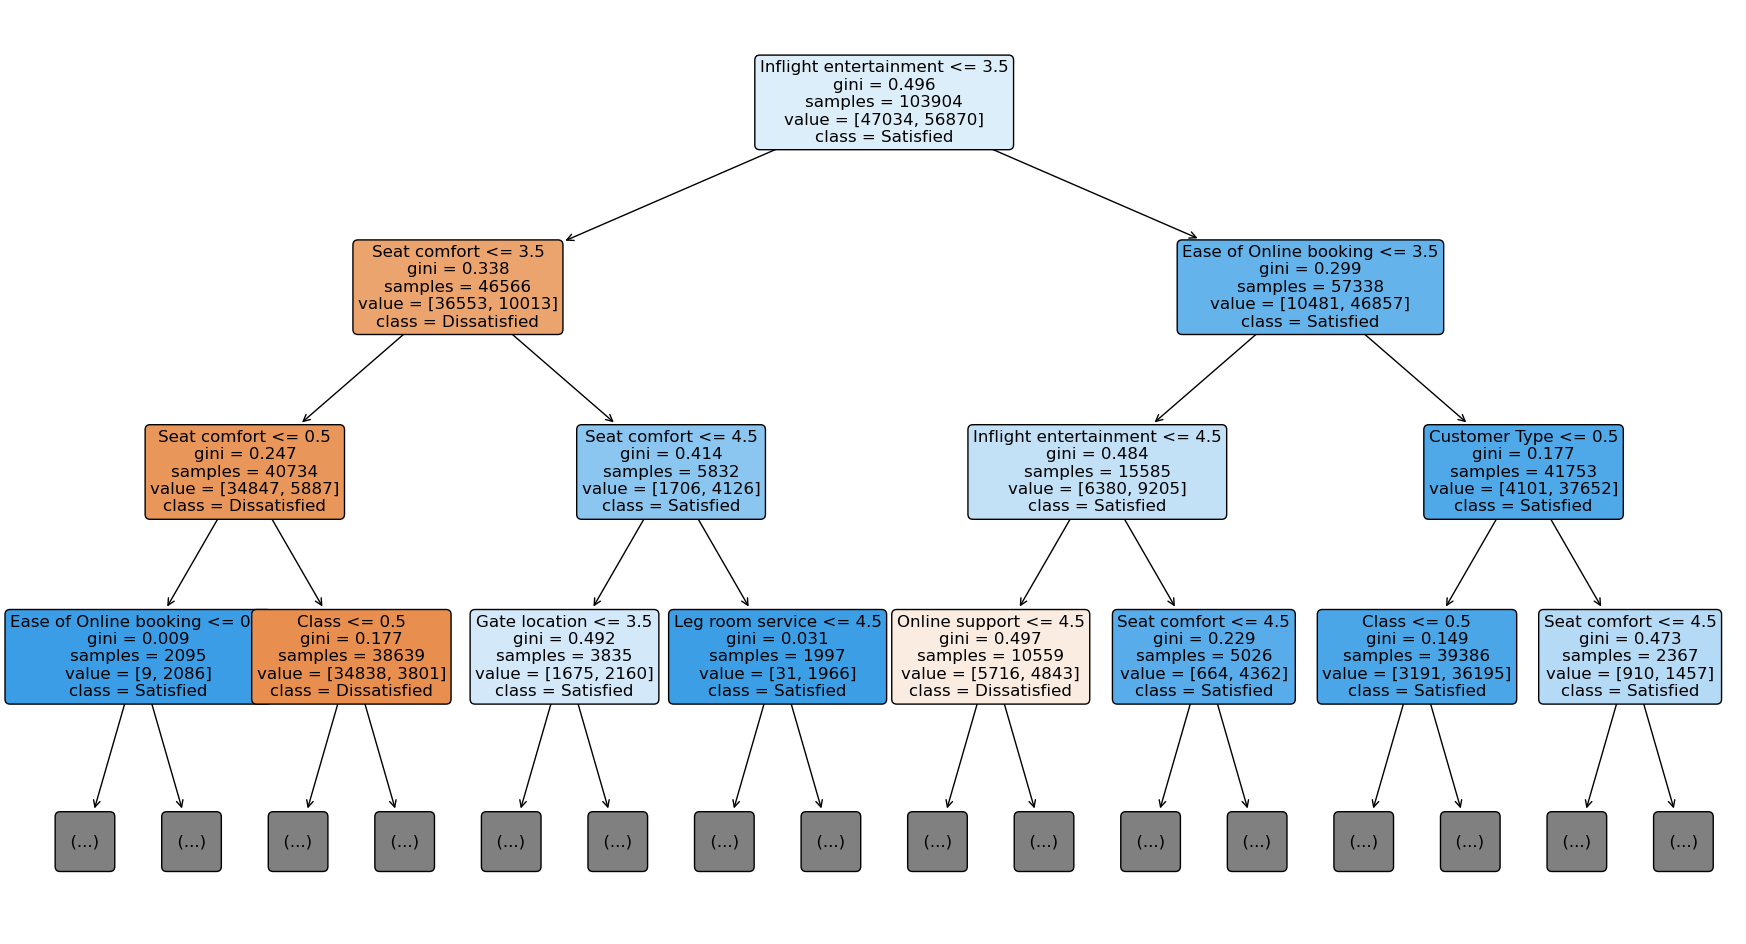

In [31]:
plt.figure(figsize=(22,12))

plot_tree(
    best_tree,
    feature_names = X.columns,
    class_names = ["Dissatisfied","Satisfied"],
    filled = True,
    rounded = True,
    fontsize = 12,
    max_depth = 3
)

plt.show()

## Step 12: Feature Importance

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_tree.feature_importances_
})

importance = importance.sort_values(
    by = "Importance",
    ascending = False
)

importance.head(10)

,Feature,Importance
10,Inflight entertainment,0.413691
5,Seat comfort,0.183479
12,Ease of Online booking,0.067222
0,Customer Type,0.046357
8,Gate location,0.030255
4,Flight Distance,0.026399
2,Type of Travel,0.024098
3,Class,0.023305
1,Age,0.022237
6,Departure/Arrival time convenient,0.020454


### Visualization

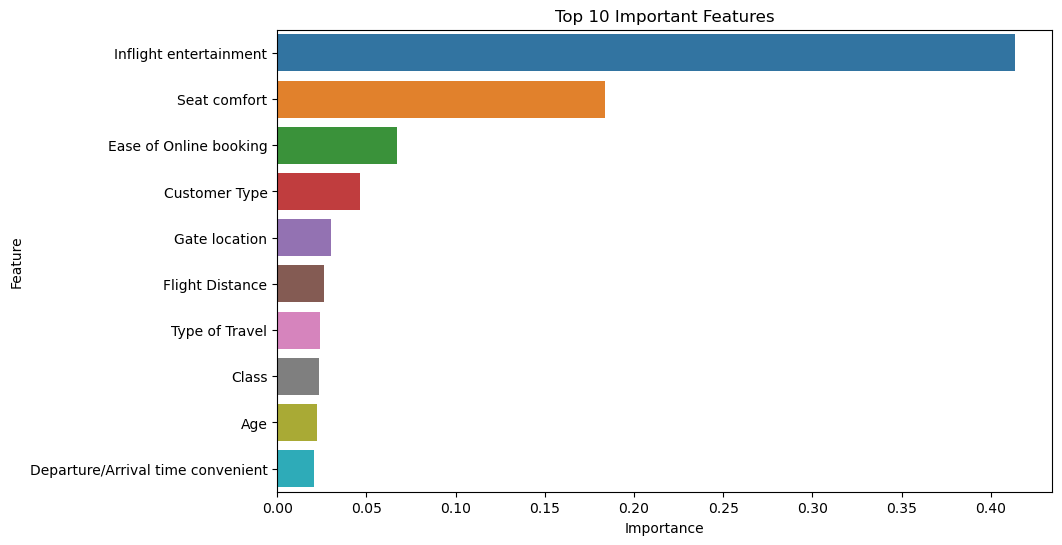

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

## Step 13: Compare with Logistic Regression


Train Logistic Regression.

In [36]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

### Evaluate.

In [37]:
print("Decision Tree")

print(classification_report(y_test, y_pred))

print()

print("Logistic Regression")

print(classification_report(y_test, log_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.92      0.94      0.93     11759
           1       0.95      0.94      0.94     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976


Logistic Regression
              precision    recall  f1-score   support

           0       0.81      0.78      0.79     11759
           1       0.82      0.84      0.83     14217

    accuracy                           0.82     25976
   macro avg       0.81      0.81      0.81     25976
weighted avg       0.82      0.82      0.82     25976



## Step 14: Interpretation

### Decision Tree Algorithm

**Advantages**

* Easy to interpret
* Can be visualized
* Captures nonlinear relationships
* Provides feature importance

**Disadvantages**

* Can overfit without pruning
* Sensitive to small changes in data

### Logistic Regression Algorithm

**Advantages**

* Simple and fast
* Performs well on linearly separable data
* Stable predictions

**Disadvantages**

* Assumes a linear relationship
* Less interpretable for complex interactions

## Step 15: Business Insights

**Example insights based on the model output:**

* Inflight entertainment is one of the strongest predictors of customer satisfaction, suggesting that enhancing onboard entertainment options could significantly improve passenger experience.
* Online support and Ease of Online booking are influential factors, indicating that investments in digital customer service and booking platforms may increase satisfaction.
* Seat comfort consistently ranks among the most important features, highlighting the value of cabin comfort improvements.
* Leg room service also contributes meaningfully, especially for long-haul travelers.
* Departure and Arrival delays have lower importance than service-quality features, implying that while punctuality matters, the overall onboard experience has a stronger impact on satisfaction.